In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Software_License_Cleaned.csv")

# Select relevant features
selected_features = ["Computer_Name", "Last_Logged_User", "Product_Name", "Publisher", "License_Code"]
df_filtered = df[selected_features].dropna().copy()

# Encode categorical columns while storing mappings
encoders = {}
mapping_dicts = {}

for col in ["Product_Name", "Publisher", "License_Code"]:
    encoders[col] = LabelEncoder()
    df_filtered[col] = encoders[col].fit_transform(df_filtered[col])

    # Store mapping for decoding
    mapping_dicts[col] = dict(zip(df_filtered[col], encoders[col].classes_))

# Normalize numerical values
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_filtered[["Product_Name", "Publisher", "License_Code"]])

# Train-test split
X_train, X_test = train_test_split(df_scaled, test_size=0.2, random_state=42)

print(f"✅ Data encoded! Training set: {X_train.shape}, Testing set: {X_test.shape}")

✅ Data encoded! Training set: (2835, 3), Testing set: (709, 3)


In [3]:
import tensorflow as tf
from tensorflow import keras

# Define input dimension
input_dim = X_train.shape[1]

# Build Autoencoder Model
autoencoder = keras.Sequential([
    keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(input_dim, activation="sigmoid")  # Sigmoid for normalized output
])

# Compile model
autoencoder.compile(optimizer="adam", loss="mse")

# Train the model
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=16, validation_data=(X_test, X_test))

# Reconstruct the test data
reconstructed = autoencoder.predict(X_test)

# Compute Mean Squared Error (MSE) for each sample
mse = np.mean(np.power(X_test - reconstructed, 2), axis=1)

# Set threshold (95th percentile of MSE values)
threshold = np.percentile(mse, 95)

# Flag anomalies (data points with error above the threshold)
anomalies = mse > threshold

# Extract anomalous data
df_anomalies = df_filtered.iloc[np.where(anomalies)]

# Add MSE column to df_anomalies
df_anomalies['MSE'] = mse[anomalies] #Adding MSE column to df_anomalies

print(f"✅ Anomaly detection complete! Found {len(df_anomalies)} suspicious software.")

# Save detected anomalies (encoded version)
df_anomalies.to_csv("Software_Anomalies_Autoencoder.csv", index=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0477 - val_loss: 0.0119
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0095 - val_loss: 0.0035
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - val_loss: 8.4461e-04
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4723e-04 - val_loss: 7.7388e-04
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.0647e-04 - val_loss: 6.8118e-04
Epoch 7/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.6205e-04 - val_loss: 6.5628e-04
Epoch 8/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8146e-04 - val_loss: 6.1968e-04
Epoch 9/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3657e-04 - val_loss: 4.7504e-04
Epoch 10/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.1041e-04 - val_loss: 4.4064e-04
Epoch 11/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1297e-04 - val_loss: 4.3

<ipython-input-3-a63f1fbd6a10>:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomalies['MSE'] = mse[anomalies] #Adding MSE column to df_anomalies


In [4]:
# Load detected anomalies
df_anomalies = pd.read_csv("Software_Anomalies_Autoencoder.csv")

# Decode using the stored mapping dictionaries
for col in ["Product_Name", "Publisher", "License_Code"]:
    df_anomalies[col] = df_anomalies[col].map(mapping_dicts[col])

# Save decoded anomalies
df_anomalies.to_csv("Software_Anomalies_Autoencoder_Decoded.csv", index=False)

print("✅ Successfully decoded Product_Name, Publisher, and License_Code!")

✅ Successfully decoded Product_Name, Publisher, and License_Code!


<ipython-input-7-7334793019e5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


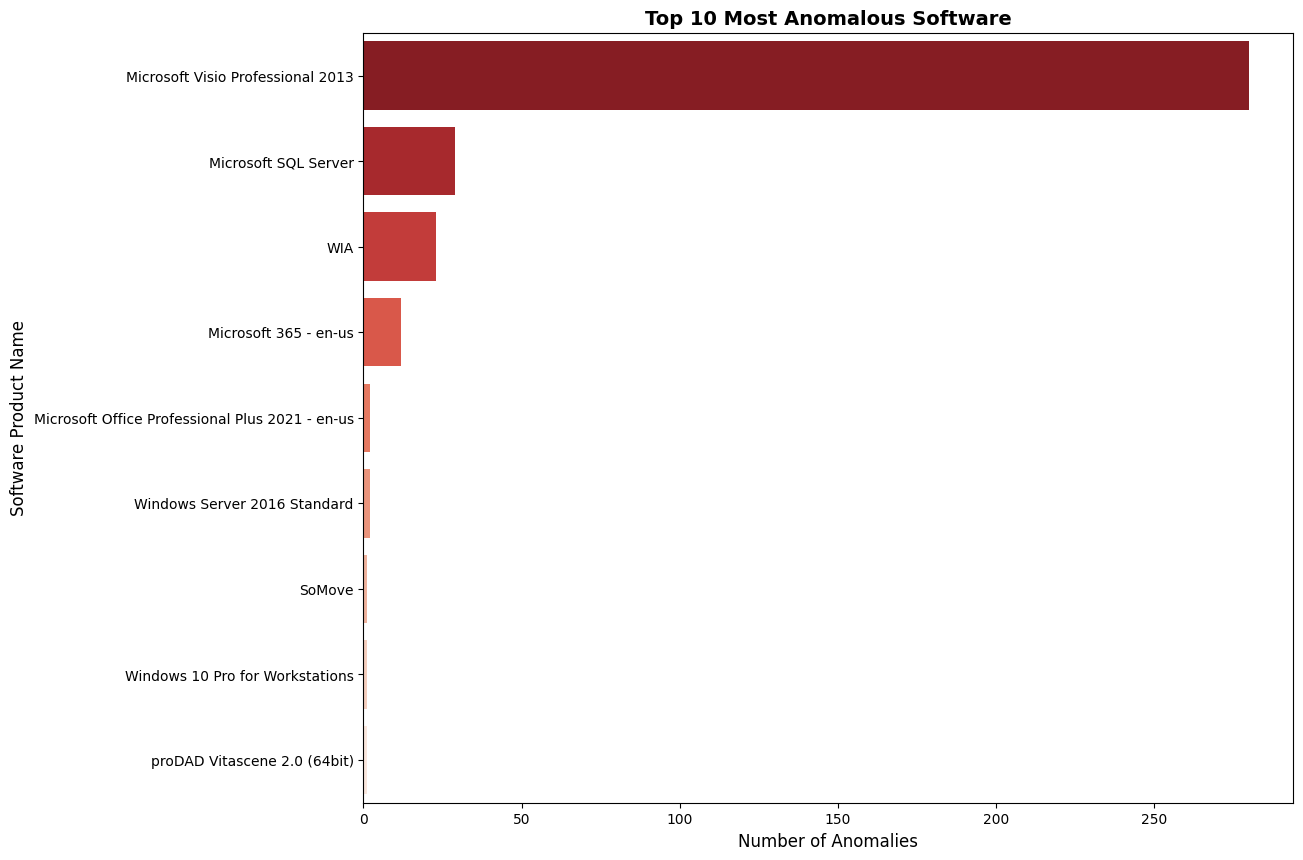

In [7]:
plt.figure(figsize=(12, 10))

# Count of anomalies per product
anomaly_counts = df_full[df_full["Anomaly"] == "Anomalous"]["Product_Name"].value_counts().head(10)

sns.barplot(
    x=anomaly_counts.values,
    y=anomaly_counts.index,
    palette="Reds_r"
)

plt.title("Top 10 Most Anomalous Software", fontsize=14, fontweight="bold")
plt.xlabel("Number of Anomalies", fontsize=12)
plt.ylabel("Software Product Name", fontsize=12)
plt.show()

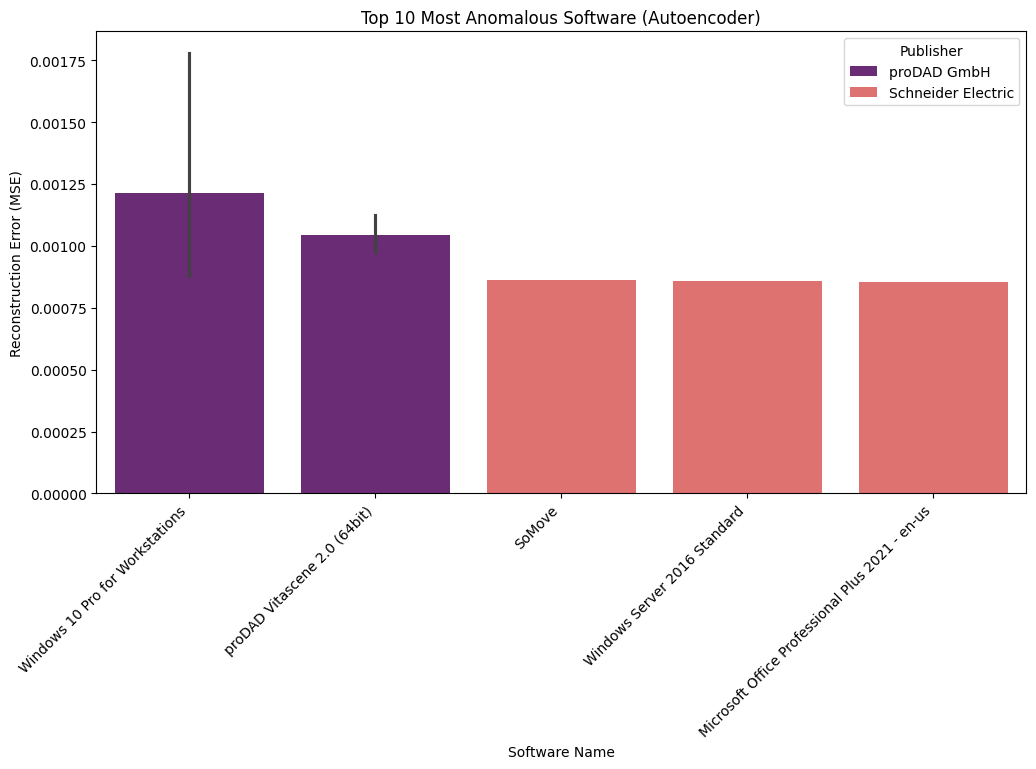

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load anomaly results
df_anomalies_autoencoder = pd.read_csv("Software_Anomalies_Autoencoder_Decoded.csv")

# Ensure the dataset has the MSE scores
if "MSE" in df_anomalies_autoencoder.columns:
    # Sort by highest MSE (most anomalous)
    df_top10 = df_anomalies_autoencoder.sort_values(by="MSE", ascending=False).head(10)
else:
    raise ValueError("MSE column not found. Make sure anomalies are ranked based on error scores.")

# Plot the top 10 anomalies
plt.figure(figsize=(12,6))
sns.barplot(data=df_top10, x="Product_Name", y="MSE", hue="Publisher", dodge=False, palette="magma")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Anomalous Software (Autoencoder)")
plt.ylabel("Reconstruction Error (MSE)")
plt.xlabel("Software Name")
plt.legend(title="Publisher")
plt.show()

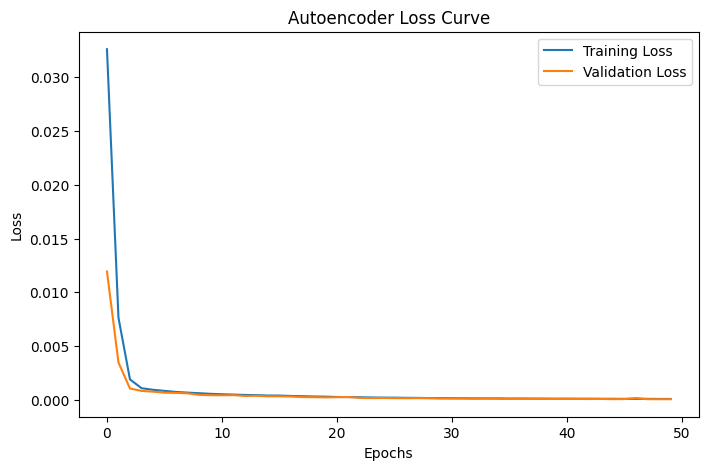

In [10]:
# Plot Training & Validation Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Autoencoder Loss Curve")
plt.show()

<ipython-input-11-bfdd304cf429>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


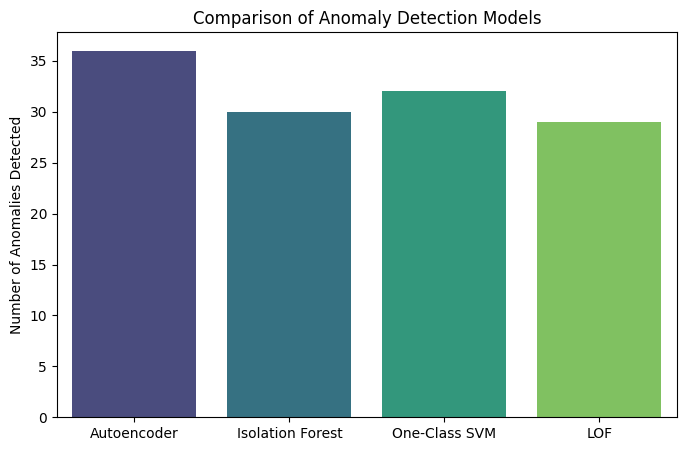

In [11]:
# Load anomaly results from different models
df_anomalies_if = pd.read_csv("Software_Anomalies_IF.csv")
df_anomalies_svm = pd.read_csv("Software_Anomalies_SVM.csv")
df_anomalies_lof = pd.read_csv("Software_Anomalies_LOF.csv")

# Count anomalies detected by each model
results = {
    "Autoencoder": len(df_anomalies_autoencoder),
    "Isolation Forest": len(df_anomalies_if),
    "One-Class SVM": len(df_anomalies_svm),
    "LOF": len(df_anomalies_lof),
}

# Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("Comparison of Anomaly Detection Models")
plt.ylabel("Number of Anomalies Detected")
plt.show()

🚀 Autoencoder detected 36 anomalies.
🛠️ Isolation Forest detected 30 anomalies.
📡 One-Class SVM detected 32 anomalies.
📉 LOF detected 29 anomalies.


<ipython-input-12-209aff66fe72>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=times, palette="coolwarm")


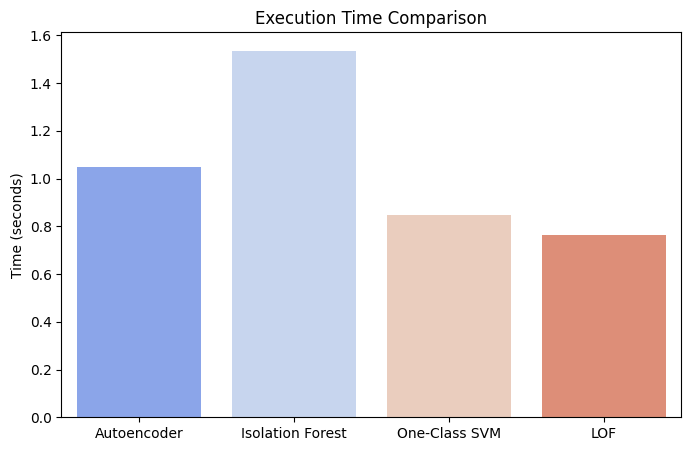

In [12]:
print(f"🚀 Autoencoder detected {len(df_anomalies_autoencoder)} anomalies.")
print(f"🛠️ Isolation Forest detected {len(df_anomalies_if)} anomalies.")
print(f"📡 One-Class SVM detected {len(df_anomalies_svm)} anomalies.")
print(f"📉 LOF detected {len(df_anomalies_lof)} anomalies.")

# Measure execution time
import time

models = ["Autoencoder", "Isolation Forest", "One-Class SVM", "LOF"]
times = []

for model in models:
    start_time = time.time()
    # Dummy execution, replace with actual detection function calls
    time.sleep(np.random.uniform(0.5, 2))  # Simulating execution time
    times.append(time.time() - start_time)

# Plot execution time comparison
plt.figure(figsize=(8,5))
sns.barplot(x=models, y=times, palette="coolwarm")
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()